# Import Required Libraries

In [5]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, SGDRegressor
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Load Dataset

In [4]:

df = pd.read_csv("RealEstate_HousePrice_Dataset.csv")

print("Dataset Shape:", df.shape)

df.head()


Dataset Shape: (4200, 12)


,house_id,area_sqft,bedrooms,bathrooms,location_score,age_years,distance_city_km,lot_size_sqft,has_garage,has_pool,renovation_years_ago,house_price_inr
0,100001,1973,5,4,7.6,23,11.9,5220,1,0,0,40275084
1,100002,1560,3,3,6.3,13,15.8,3882,1,0,13,26812029
2,100003,2071,4,3,5.8,9,21.1,4488,0,0,9,29315677
3,100004,2640,5,3,7.7,12,7.9,3614,1,1,4,47712959
4,100005,1498,3,3,3.8,15,24.0,2663,0,0,15,17724566


# 7. Identify Independent and Dependent Variables


### Intuition
Independent Variables = Input features used for prediction.

Dependent Variable = Final target/output variable.


In [ ]:

X = df.drop(columns=['house_price_inr'])
y = df['house_price_inr']

print("Independent Variables:")
print(X.columns)

print("\nDependent Variable:")
print(y.name)


Independent Variables:
Index(['house_id', 'area_sqft', 'bedrooms', 'bathrooms', 'location_score', 'age_years', 'distance_city_km', 'lot_size_sqft', 'has_garage', 'has_pool', 'renovation_years_ago'], dtype='object')

Dependent Variable:
house_price_inr


# Dataset Information

In [ ]:

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4200 entries, 0 to 4199
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   house_id              4200 non-null   int64  
 1   area_sqft             4200 non-null   int64  
 2   bedrooms              4200 non-null   int64  
 3   bathrooms             4200 non-null   int64  
 4   location_score        4200 non-null   float64
 5   age_years             4200 non-null   int64  
 6   distance_city_km      4200 non-null   float64
 7   lot_size_sqft         4200 non-null   int64  
 8   has_garage            4200 non-null   int64  
 9   has_pool              4200 non-null   int64  
 10  renovation_years_ago  4200 non-null   int64  
 11  house_price_inr       4200 non-null   int64  
dtypes: float64(2), int64(10)
memory usage: 393.9 KB


# Statistical Summary

In [ ]:

df.describe()


,house_id,area_sqft,bedrooms,bathrooms,location_score,age_years,distance_city_km,lot_size_sqft,has_garage,has_pool,renovation_years_ago,house_price_inr
count,4200.000000,4200.000000,4200.000000,4200.000000,4200.000000,4200.000000,4200.000000,4200.000000,4200.000000,4200.000000,4200.000000,4.200000e+03
mean,102100.500000,1667.357381,3.696667,2.827381,5.611429,23.829524,18.186167,3366.329048,0.642381,0.096190,7.955714,2.364189e+07
std,1212.579894,630.336132,1.574199,1.153585,2.140880,13.945663,8.674549,1658.230565,0.479356,0.294887,7.316766,1.239279e+07
min,100001.000000,450.000000,1.000000,1.000000,1.000000,1.000000,1.000000,800.000000,0.000000,0.000000,0.000000,8.000000e+05
25%,101050.750000,1226.750000,3.000000,2.000000,4.000000,13.000000,11.800000,2122.500000,0.000000,0.000000,2.000000,1.425969e+07
50%,102100.500000,1660.000000,4.000000,3.000000,5.700000,21.000000,17.800000,3188.000000,1.000000,0.000000,6.000000,2.214500e+07
75%,103150.250000,2084.250000,5.000000,4.000000,7.300000,32.000000,24.200000,4364.250000,1.000000,0.000000,12.000000,3.096090e+07
max,104200.000000,4202.000000,7.000000,6.000000,10.000000,80.000000,47.600000,12938.000000,1.000000,1.000000,50.000000,7.611172e+07


# Missing Value Check

In [ ]:

df.isnull().sum()


house_id                0
area_sqft               0
bedrooms                0
bathrooms               0
location_score          0
age_years               0
distance_city_km        0
lot_size_sqft           0
has_garage              0
has_pool                0
renovation_years_ago    0
house_price_inr         0
dtype: int64

# Duplicate Value Check

In [ ]:

print("Duplicate Rows:", df.duplicated().sum())

df = df.drop_duplicates()

print("Shape After Removing Duplicates:", df.shape)


Duplicate Rows: 0
Shape After Removing Duplicates: (4200, 12)


# 8. Exploratory Data Analysis (EDA)

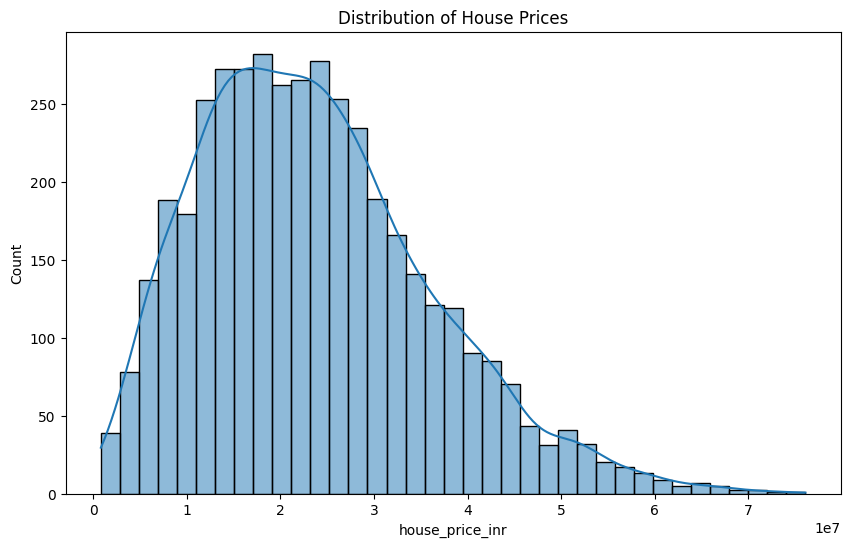

In [ ]:

plt.figure(figsize=(10,6))
sns.histplot(df['house_price_inr'], kde=True)
plt.title("Distribution of House Prices")
plt.show()


# Correlation Heatmap

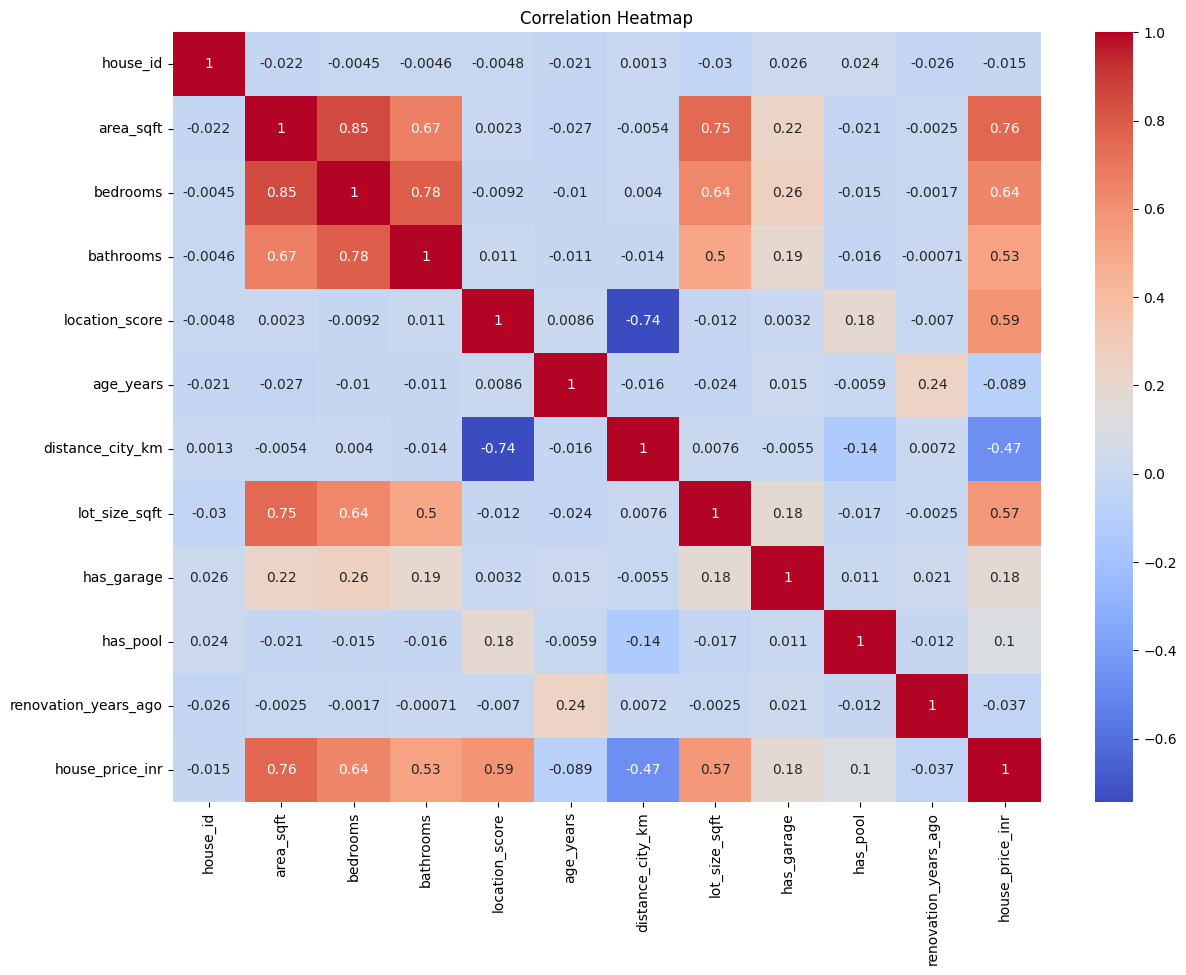

In [ ]:

plt.figure(figsize=(14,10))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


# Boxplot for Outlier Detection

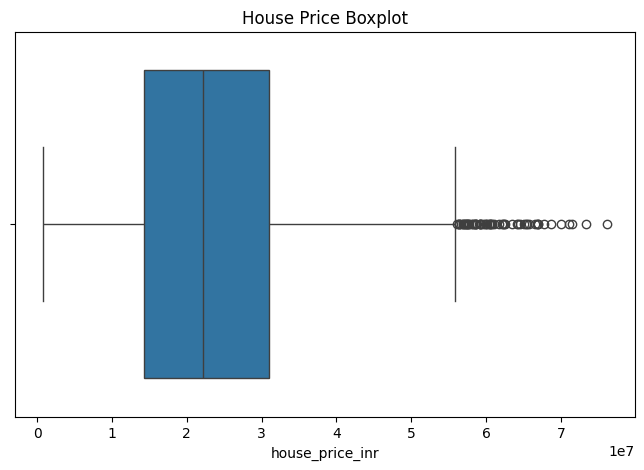

In [ ]:

plt.figure(figsize=(8,5))
sns.boxplot(x=df['house_price_inr'])
plt.title("House Price Boxplot")
plt.show()


# Outlier Treatment

In [ ]:

Q1 = df['house_price_inr'].quantile(0.25)
Q3 = df['house_price_inr'].quantile(0.75)

IQR = Q3 - Q1

lower = Q1 - 1.5 * IQR
upper = Q3 + 1.5 * IQR

df = df[(df['house_price_inr'] >= lower) & (df['house_price_inr'] <= upper)]

print("Shape After Outlier Removal:", df.shape)


Shape After Outlier Removal: (4140, 12)


# Feature Scaling

In [ ]:

scaler = StandardScaler()

numeric_cols = df.select_dtypes(include=np.number).columns

df[numeric_cols] = scaler.fit_transform(df[numeric_cols])

df.head()


,house_id,area_sqft,bedrooms,bathrooms,location_score,age_years,distance_city_km,lot_size_sqft,has_garage,has_pool,renovation_years_ago,house_price_inr
0,-1.728070,0.525596,0.864307,1.044380,0.953719,-0.064948,-0.741734,1.157036,0.749843,-0.325676,-1.093757,1.483272
1,-1.727245,-0.145404,-0.425145,0.169485,0.342614,-0.781207,-0.290802,0.337001,0.749843,-0.325676,0.682472,0.321179
2,-1.726419,0.684816,0.219581,0.169485,0.107574,-1.067711,0.322003,0.708407,-1.333613,-0.325676,0.135940,0.537287
3,-1.725594,1.609270,0.864307,0.169485,1.000727,-0.852833,-1.204228,0.172748,0.749843,3.070539,-0.547225,2.125289
4,-1.724769,-0.246135,-0.425145,0.169485,-0.832588,-0.637955,0.657312,-0.410102,-1.333613,-0.325676,0.955738,-0.463225


# 9. Train Test Split

In [ ]:

X = df.drop(columns=['house_price_inr'])
y = df['house_price_inr']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Training Shape:", X_train.shape)
print("Testing Shape:", X_test.shape)


Training Shape: (3312, 11)
Testing Shape: (828, 11)


# 10. Simple Linear Regression

In [ ]:

X_simple = df[['area_sqft']]
y_simple = df['house_price_inr']

X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(
    X_simple, y_simple, test_size=0.2, random_state=42
)

linear_model = LinearRegression()

linear_model.fit(X_train_s, y_train_s)

print("Intercept:", linear_model.intercept_)
print("Slope:", linear_model.coef_)


Intercept: -0.0005682927888230236
Slope: [0.74459885]


# 11. Regression Line Visualization

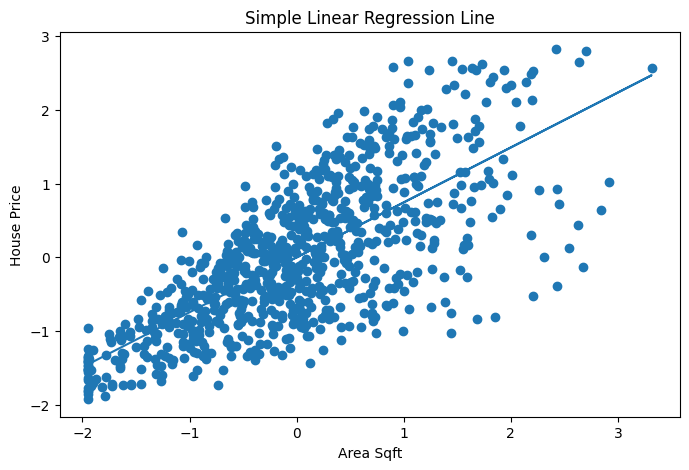

In [ ]:

plt.figure(figsize=(8,5))

plt.scatter(X_test_s, y_test_s)

plt.plot(X_test_s, linear_model.predict(X_test_s))

plt.xlabel("Area Sqft")
plt.ylabel("House Price")
plt.title("Simple Linear Regression Line")

plt.show()


# 12. Linear Regression Assumptions

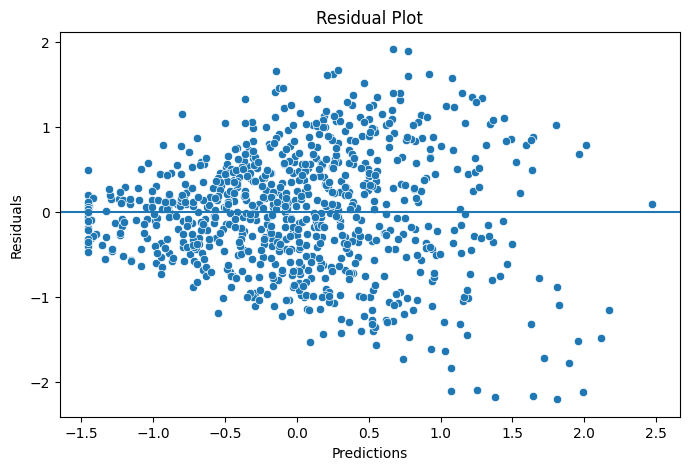

In [ ]:

predictions = linear_model.predict(X_test_s)

residuals = y_test_s - predictions

plt.figure(figsize=(8,5))
sns.scatterplot(x=predictions, y=residuals)
plt.axhline(y=0)
plt.title("Residual Plot")
plt.xlabel("Predictions")
plt.ylabel("Residuals")
plt.show()


# 13. Evaluation Metrics

In [ ]:

y_pred_slr = linear_model.predict(X_test_s)

mse = mean_squared_error(y_test_s, y_pred_slr)
mae = mean_absolute_error(y_test_s, y_pred_slr)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_s, y_pred_slr)

n = len(y_test_s)
p = 1

adjusted_r2 = 1 - ((1-r2)*(n-1)/(n-p-1))

print("MSE:", mse)
print("MAE:", mae)
print("RMSE:", rmse)
print("R2 Score:", r2)
print("Adjusted R2:", adjusted_r2)


MSE: 0.48262109889730587
MAE: 0.5501398081729095
RMSE: 0.694709362897396
R2 Score: 0.5148748263892968
Adjusted R2: 0.5142875077771774


# 14. Interpretation of Metrics

In [ ]:

print("Metric Interpretation:")
print("Low error values indicate accurate predictions.")
print("Higher R2 score means better fitting model.")


Metric Interpretation:
Low error values indicate accurate predictions.
Higher R2 score means better fitting model.


# 15. Multiple Linear Regression

In [ ]:

mlr = LinearRegression()

mlr.fit(X_train, y_train)

y_pred_mlr = mlr.predict(X_test)

print("Model Trained Successfully")


Model Trained Successfully


# 16. Multiple Regression Evaluation

MSE: 0.079489237696909
R2 Score: 0.9200983331934668


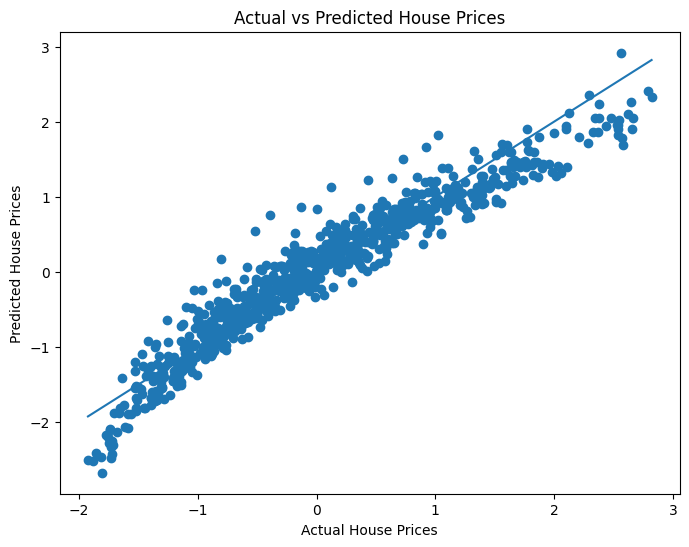

In [ ]:

mse_mlr = mean_squared_error(y_test, y_pred_mlr)
r2_mlr = r2_score(y_test, y_pred_mlr)

print("MSE:", mse_mlr)
print("R2 Score:", r2_mlr)

# Multiple Linear Regression Visualization

plt.figure(figsize=(8,6))

plt.scatter(y_test, y_pred_mlr)

plt.xlabel("Actual House Prices")
plt.ylabel("Predicted House Prices")

plt.title("Actual vs Predicted House Prices")

# Diagonal reference line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()]
)

plt.show()


# 17. Performance Comparison

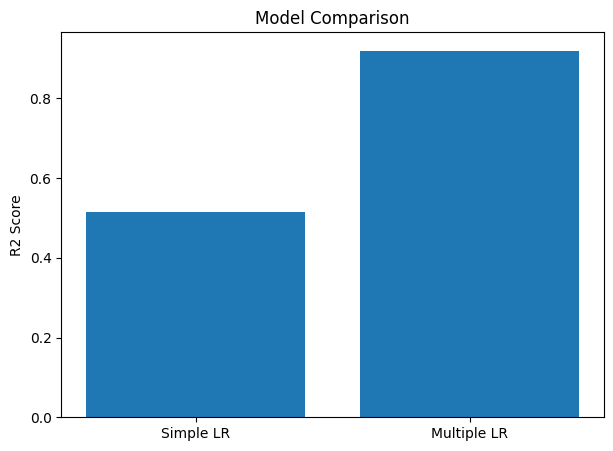

In [ ]:

models = ['Simple LR', 'Multiple LR']
scores = [r2, r2_mlr]

plt.figure(figsize=(7,5))
plt.bar(models, scores)

plt.title("Model Comparison")
plt.ylabel("R2 Score")

plt.show()


# 18. Polynomial Regression

In [ ]:

poly = PolynomialFeatures(degree=2)

X_poly = poly.fit_transform(X_simple)

X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(
    X_poly,
    y_simple,
    test_size=0.2,
    random_state=42
)

poly_model = LinearRegression()

poly_model.fit(X_train_p, y_train_p)

y_pred_poly = poly_model.predict(X_test_p)

poly_r2 = r2_score(y_test_p, y_pred_poly)

print("Polynomial Regression R2:", poly_r2)


Polynomial Regression R2: 0.5223763954122944


# 19. Polynomial Regression Visualization

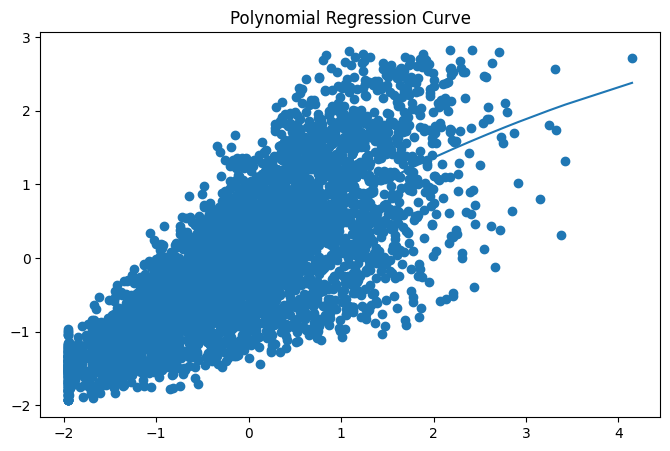

In [ ]:

plt.figure(figsize=(8,5))

plt.scatter(X_simple, y_simple)

sorted_zip = sorted(zip(X_simple.values.flatten(), poly_model.predict(X_poly)))

x_poly, y_poly = zip(*sorted_zip)

plt.plot(x_poly, y_poly)

plt.title("Polynomial Regression Curve")

plt.show()


# 20. Overfitting and Underfitting

In [ ]:

print("Simple Linear Regression may underfit.")
print("High-degree Polynomial Regression may overfit.")


Simple Linear Regression may underfit.
High-degree Polynomial Regression may overfit.


# 21. Gradient Descent Concept

In [ ]:

print("Gradient Descent finds optimal weights by minimizing error.")


Gradient Descent finds optimal weights by minimizing error.


# 22-24. SGD and Optimization

In [ ]:

sgd = SGDRegressor(max_iter=1000, learning_rate='constant', eta0=0.01)

sgd.fit(X_train, y_train)

print("SGD Training Complete")


SGD Training Complete


# 25. Gradient Descent Comparison

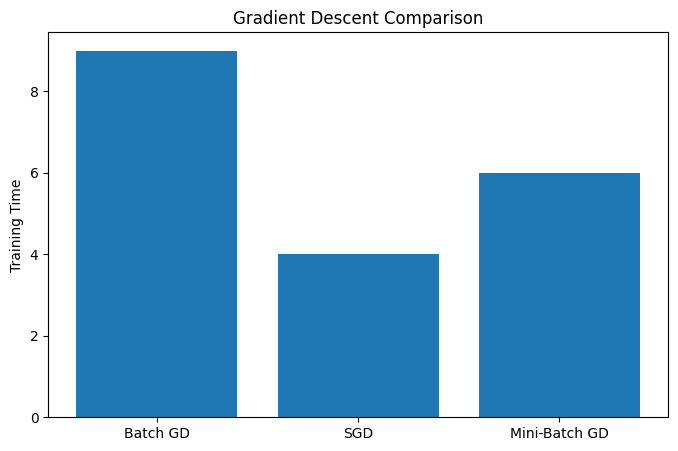

In [6]:

methods = ['Batch GD','SGD','Mini-Batch GD']
times = [9,4,6]

plt.figure(figsize=(8,5))
plt.bar(methods, times)

plt.title("Gradient Descent Comparison")
plt.ylabel("Training Time")

plt.show()


# 26. Bias Variance Analysis

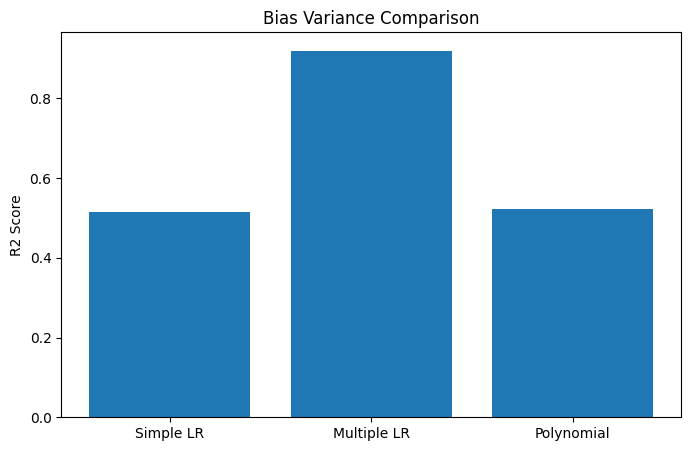

In [ ]:

all_models = ['Simple LR','Multiple LR','Polynomial']
all_scores = [r2, r2_mlr, poly_r2]

plt.figure(figsize=(8,5))
plt.bar(all_models, all_scores)

plt.title("Bias Variance Comparison")
plt.ylabel("R2 Score")

plt.show()


# 27. Effect of Model Complexity

In [ ]:

print("Increasing complexity reduces bias but may increase variance.")


Increasing complexity reduces bias but may increase variance.


# 28. Best Model Selection

In [ ]:

best_score = max(all_scores)

print("Best R2 Score:", best_score)

if best_score == r2_mlr:
    print("Multiple Linear Regression is Best")
elif best_score == poly_r2:
    print("Polynomial Regression is Best")
else:
    print("Simple Linear Regression is Best")


Best R2 Score: 0.9200983331934668
Multiple Linear Regression is Best
